# 🐦 Crow Search Algorithm (CSA) — Entrenamiento de MLP para aproximar sin(x)

**Taller: Computación Blanda — Algoritmos Bio-Inspirados**

---

**Objetivo:** Entrenar una Red Neuronal MLP desde cero usando el Crow Search Algorithm (CSA) como optimizador, **sin backpropagation**, para aproximar la función:

$$y = \sin(x), \quad x \in [-\pi, \pi]$$

---

**Arquitectura MLP obligatoria:**
- Entrada: 1 neurona
- Capa oculta 1: 2 neuronas (activación sigmoide)
- Capa oculta 2: 2 neuronas (activación sigmoide)
- Salida: 1 neurona (activación identidad)
- **Total de parámetros: 13**

---

**Sobre el CSA:** El Crow Search Algorithm (Askarzadeh, 2016) es un algoritmo bio-inspirado basado en el comportamiento inteligente de los cuervos. Los cuervos esconden comida y recuerdan dónde la guardaron. También siguen a otros cuervos para robar sus escondites. Este comportamiento se modela como búsqueda en el espacio de soluciones.

---
## 1. Librerías e Importaciones

In [36]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy
import time
from pathlib import Path
import zipfile
import json

# Semilla para reproducibilidad
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')

# ─────────────────────────────────────────────────
# Guardado automático de gráficas
# ─────────────────────────────────────────────────
PROJECT_DIR = Path.cwd()
NOTEBOOK_DIR = PROJECT_DIR if (PROJECT_DIR / 'CSA_MLP_sin_notebook.ipynb').exists() else (PROJECT_DIR / 'Crow' / 'otra')
OUTPUT_DIR = NOTEBOOK_DIR / 'salidas_taller_csa'
FIG_DIR = OUTPUT_DIR / 'figuras'
DOC_DIR = OUTPUT_DIR / 'documentos'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DOC_DIR.mkdir(parents=True, exist_ok=True)

if not hasattr(plt, '_original_show_csa'):
    plt._original_show_csa = plt.show
if not hasattr(plt, '_auto_fig_counter_csa'):
    plt._auto_fig_counter_csa = 1

def _show_and_save(*args, **kwargs):
    fig = plt.gcf()
    fig_name = f'fig_{plt._auto_fig_counter_csa:02d}.png'
    fig_path = FIG_DIR / fig_name
    fig.savefig(fig_path, dpi=180, bbox_inches='tight')
    print(f'💾 Gráfica guardada: {fig_path}')
    plt._auto_fig_counter_csa += 1
    return plt._original_show_csa(*args, **kwargs)

plt.show = _show_and_save

print('✅ Librerías cargadas correctamente.')
print(f'   NumPy version: {np.__version__}')
print(f'   Carpeta de salida: {OUTPUT_DIR}')

✅ Librerías cargadas correctamente.
   NumPy version: 2.4.3
   Carpeta de salida: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa


---
## 2. Dataset — Muestreo de sin(x)

Dataset de entrenamiento: 100 puntos
Dataset de prueba:        200 puntos
Rango x: [-3.1416, 3.1416]
Rango y: [-0.9999, 0.9999]
💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_01.png


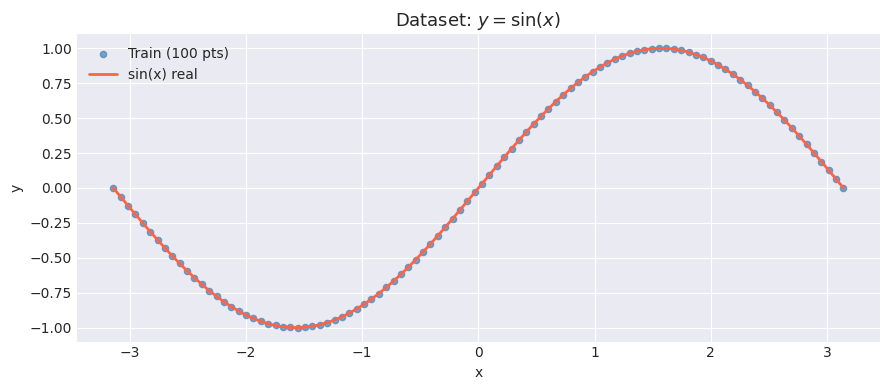

In [37]:
# ─────────────────────────────────────────────────
# Generación del dataset de entrenamiento y prueba
# ─────────────────────────────────────────────────
N_TRAIN = 100   # puntos de entrenamiento
N_TEST  = 200   # puntos de prueba (más denso para visualización)

X_train = np.linspace(-np.pi, np.pi, N_TRAIN).reshape(-1, 1)
y_train = np.sin(X_train).reshape(-1, 1)

X_test  = np.linspace(-np.pi, np.pi, N_TEST).reshape(-1, 1)
y_test  = np.sin(X_test).reshape(-1, 1)

print(f'Dataset de entrenamiento: {X_train.shape[0]} puntos')
print(f'Dataset de prueba:        {X_test.shape[0]} puntos')
print(f'Rango x: [{X_train.min():.4f}, {X_train.max():.4f}]')
print(f'Rango y: [{y_train.min():.4f}, {y_train.max():.4f}]')

# Visualización del dataset
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_train, y_train, s=20, color='steelblue', alpha=0.7, label='Train (100 pts)')
ax.plot(X_test, y_test, color='tomato', lw=2, label='sin(x) real')
ax.set_title('Dataset: $y = \\sin(x)$', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Arquitectura MLP — Implementación desde cero

La MLP tiene la siguiente estructura de parámetros (13 en total):

| Sección | Parámetros | Cantidad |
|---|---|---|
| W1: entrada→oculta1 | 1×2 pesos | 2 |
| b1: bias oculta1 | 2 bias | 2 |
| W2: oculta1→oculta2 | 2×2 pesos | 4 |
| b2: bias oculta2 | 2 bias | 2 |
| W3: oculta2→salida | 2×1 pesos | 2 |
| b3: bias salida | 1 bias | 1 |
| **Total** | | **13** |

In [21]:
# ─────────────────────────────────────────────────
# MLP implementada desde cero con NumPy
# Arquitectura: 1 → 2 → 2 → 1
# ─────────────────────────────────────────────────

N_PARAMS = 13  # total de parámetros

def sigmoid(z):
    """Función de activación sigmoide, numéricamente estable."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def decode_weights(theta):
    """
    Decodifica el vector de 13 parámetros en matrices de pesos y bias.
    Estructura:
      theta[0:2]   → W1 (1×2)
      theta[2:4]   → b1 (2,)
      theta[4:8]   → W2 (2×2)
      theta[8:10]  → b2 (2,)
      theta[10:12] → W3 (2×1)
      theta[12]    → b3 (1,)
    """
    W1 = theta[0:2].reshape(1, 2)    # (1 entrada → 2 neuronas)
    b1 = theta[2:4].reshape(1, 2)
    W2 = theta[4:8].reshape(2, 2)    # (2 → 2 neuronas)
    b2 = theta[8:10].reshape(1, 2)
    W3 = theta[10:12].reshape(2, 1)  # (2 → 1 salida)
    b3 = theta[12:13].reshape(1, 1)
    return W1, b1, W2, b2, W3, b3

def forward(X, theta):
    """
    Forward pass de la MLP.
    X: array de forma (N, 1)
    theta: vector de 13 parámetros
    Retorna: predicciones (N, 1)
    """
    W1, b1, W2, b2, W3, b3 = decode_weights(theta)
    
    # Capa 1: sigmoide
    z1 = X @ W1 + b1          # (N, 2)
    a1 = sigmoid(z1)           # (N, 2)
    
    # Capa 2: sigmoide
    z2 = a1 @ W2 + b2         # (N, 2)
    a2 = sigmoid(z2)           # (N, 2)
    
    # Capa salida: identidad
    z3 = a2 @ W3 + b3         # (N, 1)
    return z3                  # identidad: f(z) = z

def mse(theta, X, y):
    """
    Función de fitness: MSE entre predicción y valor real.
    Minimizar MSE(θ) = (1/N) * Σ (ŷ_i - y_i)²
    """
    y_pred = forward(X, theta)
    return np.mean((y_pred - y) ** 2)

# ── Verificación de dimensiones ──
theta_test = np.random.randn(N_PARAMS)
y_pred_test = forward(X_train[:5], theta_test)
mse_test = mse(theta_test, X_train, y_train)

print('✅ MLP verificada correctamente.')
print(f'   Número de parámetros: {N_PARAMS}')
print(f'   Shape salida (5 muestras): {y_pred_test.shape}')
print(f'   MSE inicial (pesos aleatorios): {mse_test:.6f}')

✅ MLP verificada correctamente.
   Número de parámetros: 13
   Shape salida (5 muestras): (5, 1)
   MSE inicial (pesos aleatorios): 0.642207


---
## 4. Crow Search Algorithm (CSA)

### Descripción del algoritmo

El CSA simula el comportamiento de los cuervos: cada cuervo $i$ tiene una posición $\mathbf{x}^i$ (solución candidata) y una memoria $\mathbf{m}^i$ (mejor posición encontrada). En cada iteración:

1. Se selecciona aleatoriamente un cuervo objetivo $j$
2. Con probabilidad $AP$ (Awareness Probability) el cuervo $j$ detecta que lo siguen → el cuervo $i$ va a una posición aleatoria
3. Con probabilidad $1 - AP$ el cuervo $j$ no detecta → el cuervo $i$ sigue al $j$ hacia su escondite
4. Se actualizan memorias si la nueva posición es mejor

**Ecuación de actualización de posición:**

$$\mathbf{x}^{i,t+1} = \begin{cases} \mathbf{x}^{i,t} + r_i \cdot fl \cdot (\mathbf{m}^{j,t} - \mathbf{x}^{i,t}) & \text{si } r_j \geq AP \\ \text{posición aleatoria} & \text{si } r_j < AP \end{cases}$$

Donde $fl$ es el *flight length* (longitud de vuelo) y $r_i, r_j \sim U(0,1)$.

In [22]:
# ─────────────────────────────────────────────────
# CROW SEARCH ALGORITHM (CSA)
# Adaptado para entrenar la MLP (minimizar MSE)
# ─────────────────────────────────────────────────

class CSA:
    """
    Crow Search Algorithm para optimización continua.
    
    Parámetros:
    -----------
    n_crows   : tamaño de la población (número de cuervos)
    max_iter  : número máximo de iteraciones
    fl        : flight length — controla el paso de búsqueda
    ap        : awareness probability — probabilidad de detección
    dim       : dimensión del espacio de búsqueda (= N_PARAMS)
    lb, ub    : límites inferior y superior del espacio
    fitness_fn: función de fitness a minimizar (MSE)
    seed      : semilla aleatoria
    """
    
    def __init__(self, n_crows=40, max_iter=1000, fl=2.0, ap=0.1,
                 dim=13, lb=-5.0, ub=5.0, fitness_fn=None, seed=42):
        self.n_crows   = n_crows
        self.max_iter  = max_iter
        self.fl        = fl
        self.ap        = ap
        self.dim       = dim
        self.lb        = lb
        self.ub        = ub
        self.fitness_fn = fitness_fn
        self.rng       = np.random.default_rng(seed)
        
        # Historial para análisis de convergencia
        self.history_best  = []   # mejor MSE por iteración
        self.history_mean  = []   # MSE promedio por iteración
        self.best_theta    = None
        self.best_fitness  = np.inf
    
    def _clip(self, x):
        """Mantiene la solución dentro de los límites."""
        return np.clip(x, self.lb, self.ub)
    
    def optimize(self, verbose=True):
        """
        Ejecuta el CSA y retorna el mejor vector de parámetros.
        """
        nc  = self.n_crows
        dim = self.dim
        
        # ── Paso 1: Inicialización ──────────────────────────
        # Posiciones: matriz (n_crows × dim)
        positions = self.rng.uniform(self.lb, self.ub, size=(nc, dim))
        # Memoria: cada cuervo guarda su mejor posición conocida
        memory    = positions.copy()
        
        # ── Paso 2: Evaluación inicial ──────────────────────
        fitness       = np.array([self.fitness_fn(positions[i]) for i in range(nc)])
        mem_fitness   = fitness.copy()
        
        # Mejor global inicial
        best_idx         = np.argmin(mem_fitness)
        self.best_theta  = memory[best_idx].copy()
        self.best_fitness = mem_fitness[best_idx]
        
        start_time = time.time()
        
        # ── Paso 3: Bucle principal ─────────────────────────
        for t in range(self.max_iter):
            new_positions = positions.copy()
            
            for i in range(nc):
                # Seleccionar cuervo objetivo j ≠ i de forma aleatoria
                j = self.rng.integers(0, nc)
                
                r_i = self.rng.random()   # número aleatorio para i
                r_j = self.rng.random()   # número aleatorio para j
                
                if r_j >= self.ap:
                    # El cuervo j NO detecta: i sigue a j hacia su memoria
                    new_pos = positions[i] + r_i * self.fl * (memory[j] - positions[i])
                else:
                    # El cuervo j SÍ detecta: i va a posición aleatoria
                    new_pos = self.rng.uniform(self.lb, self.ub, size=dim)
                
                new_positions[i] = self._clip(new_pos)
            
            # ── Paso 4: Evaluación de nuevas posiciones ─────
            new_fitness = np.array([self.fitness_fn(new_positions[i]) for i in range(nc)])
            
            # ── Paso 5: Actualización de posiciones ─────────
            positions = new_positions
            fitness   = new_fitness
            
            # ── Paso 6: Actualización de memorias ───────────
            improved = fitness < mem_fitness
            memory[improved]    = positions[improved].copy()
            mem_fitness[improved] = fitness[improved]
            
            # ── Actualizar mejor global ──────────────────────
            best_idx = np.argmin(mem_fitness)
            if mem_fitness[best_idx] < self.best_fitness:
                self.best_fitness = mem_fitness[best_idx]
                self.best_theta   = memory[best_idx].copy()
            
            # Registrar historial
            self.history_best.append(self.best_fitness)
            self.history_mean.append(np.mean(mem_fitness))
            
            # ── Criterio de parada anticipada ───────────────
            if self.best_fitness < 1e-5:
                if verbose:
                    print(f'  ⚡ Convergencia anticipada en iteración {t+1}')
                break
            
            # Reporte periódico
            if verbose and (t + 1) % 100 == 0:
                elapsed = time.time() - start_time
                print(f'  Iter {t+1:4d}/{self.max_iter} | '
                      f'Mejor MSE: {self.best_fitness:.6f} | '
                      f'Tiempo: {elapsed:.1f}s')
        
        elapsed_total = time.time() - start_time
        if verbose:
            print(f'\n✅ Optimización completada en {elapsed_total:.2f}s')
            print(f'   Mejor MSE encontrado: {self.best_fitness:.8f}')
        
        return self.best_theta

print('✅ Clase CSA definida correctamente.')

✅ Clase CSA definida correctamente.


---
## 5. Entrenamiento con CSA

Configuración base del experimento principal.

In [38]:
# ─────────────────────────────────────────────────
# Configuración y ejecución del entrenamiento
# ─────────────────────────────────────────────────

# Función de fitness: MSE sobre datos de entrenamiento
fitness_fn = lambda theta: mse(theta, X_train, y_train)

# Instanciar y ejecutar CSA
csa = CSA(
    n_crows  = 40,       # tamaño de población
    max_iter = 1000,     # iteraciones máximas
    fl       = 2.0,      # flight length
    ap       = 0.1,      # awareness probability
    dim      = N_PARAMS, # 13 parámetros
    lb       = -5.0,     # límite inferior
    ub       = 5.0,      # límite superior
    fitness_fn = fitness_fn,
    seed     = 42
)

print('🐦 Iniciando Crow Search Algorithm...')
print(f'   Población: {csa.n_crows} cuervos')
print(f'   Iteraciones máximas: {csa.max_iter}')
print(f'   Flight length (fl): {csa.fl}')
print(f'   Awareness Probability (AP): {csa.ap}')
print(f'   Espacio de búsqueda: [{csa.lb}, {csa.ub}]^{csa.dim}')
print('-' * 55)

best_theta = csa.optimize(verbose=True)

# Evaluar en train y test
mse_train = mse(best_theta, X_train, y_train)
mse_test  = mse(best_theta, X_test,  y_test)

print(f'\n📊 Resultados finales:')
print(f'   MSE entrenamiento: {mse_train:.8f}')
print(f'   MSE prueba:        {mse_test:.8f}')
print(f'   Mejor θ: {np.round(best_theta, 4)}')

🐦 Iniciando Crow Search Algorithm...
   Población: 40 cuervos
   Iteraciones máximas: 1000
   Flight length (fl): 2.0
   Awareness Probability (AP): 0.1
   Espacio de búsqueda: [-5.0, 5.0]^13
-------------------------------------------------------
  Iter  100/1000 | Mejor MSE: 0.043889 | Tiempo: 0.3s
  Iter  200/1000 | Mejor MSE: 0.030370 | Tiempo: 0.5s
  Iter  300/1000 | Mejor MSE: 0.024072 | Tiempo: 0.7s
  Iter  400/1000 | Mejor MSE: 0.018159 | Tiempo: 0.9s
  Iter  500/1000 | Mejor MSE: 0.015184 | Tiempo: 1.1s
  Iter  600/1000 | Mejor MSE: 0.013546 | Tiempo: 1.4s
  Iter  700/1000 | Mejor MSE: 0.012593 | Tiempo: 1.6s
  Iter  800/1000 | Mejor MSE: 0.011736 | Tiempo: 1.8s
  Iter  900/1000 | Mejor MSE: 0.009988 | Tiempo: 2.0s
  Iter 1000/1000 | Mejor MSE: 0.009433 | Tiempo: 2.3s

✅ Optimización completada en 2.26s
   Mejor MSE encontrado: 0.00943307

📊 Resultados finales:
   MSE entrenamiento: 0.00943307
   MSE prueba:        0.00912692
   Mejor θ: [-1.5036  0.6255  0.2298 -0.3491  3.714

---
## 6. Gráfica de Convergencia

💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_02.png


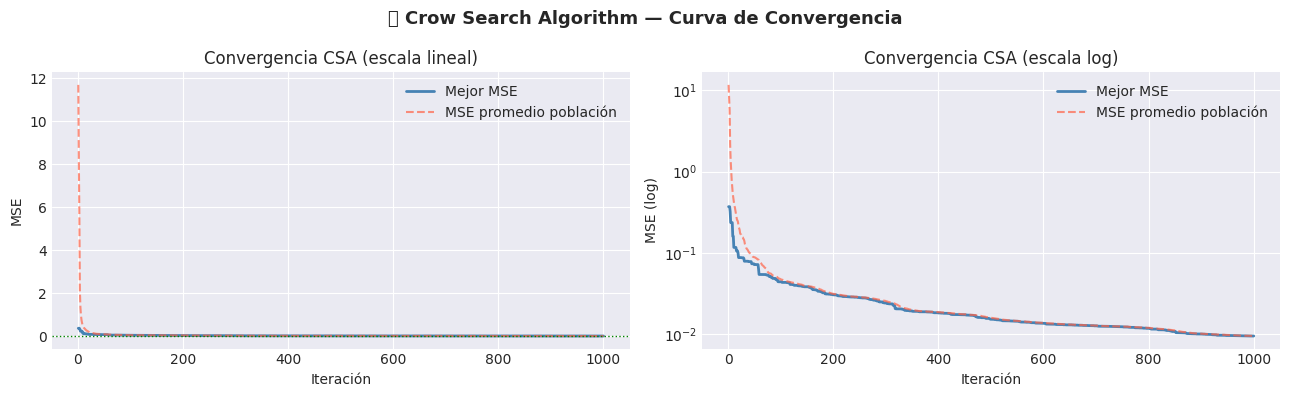

Iteraciones ejecutadas: 1000
Reducción de MSE: 0.369598 → 0.009433


In [39]:
# ─────────────────────────────────────────────────
# Gráfica 1: Curva de convergencia (MSE vs iteraciones)
# ─────────────────────────────────────────────────

iters = np.arange(1, len(csa.history_best) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ─ Escala lineal ─
axes[0].plot(iters, csa.history_best, color='steelblue', lw=2, label='Mejor MSE')
axes[0].plot(iters, csa.history_mean, color='tomato', lw=1.5,
             linestyle='--', alpha=0.7, label='MSE promedio población')
axes[0].set_title('Convergencia CSA (escala lineal)', fontsize=12)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].axhline(mse_train, color='green', lw=1, linestyle=':', label=f'Final: {mse_train:.5f}')

# ─ Escala logarítmica ─
axes[1].semilogy(iters, csa.history_best, color='steelblue', lw=2, label='Mejor MSE')
axes[1].semilogy(iters, csa.history_mean, color='tomato', lw=1.5,
                 linestyle='--', alpha=0.7, label='MSE promedio población')
axes[1].set_title('Convergencia CSA (escala log)', fontsize=12)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('MSE (log)')
axes[1].legend()

plt.suptitle('🐦 Crow Search Algorithm — Curva de Convergencia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Iteraciones ejecutadas: {len(csa.history_best)}')
print(f'Reducción de MSE: {csa.history_best[0]:.6f} → {csa.history_best[-1]:.6f}')

---
## 7. Predicción vs. Función Real

💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_03.png


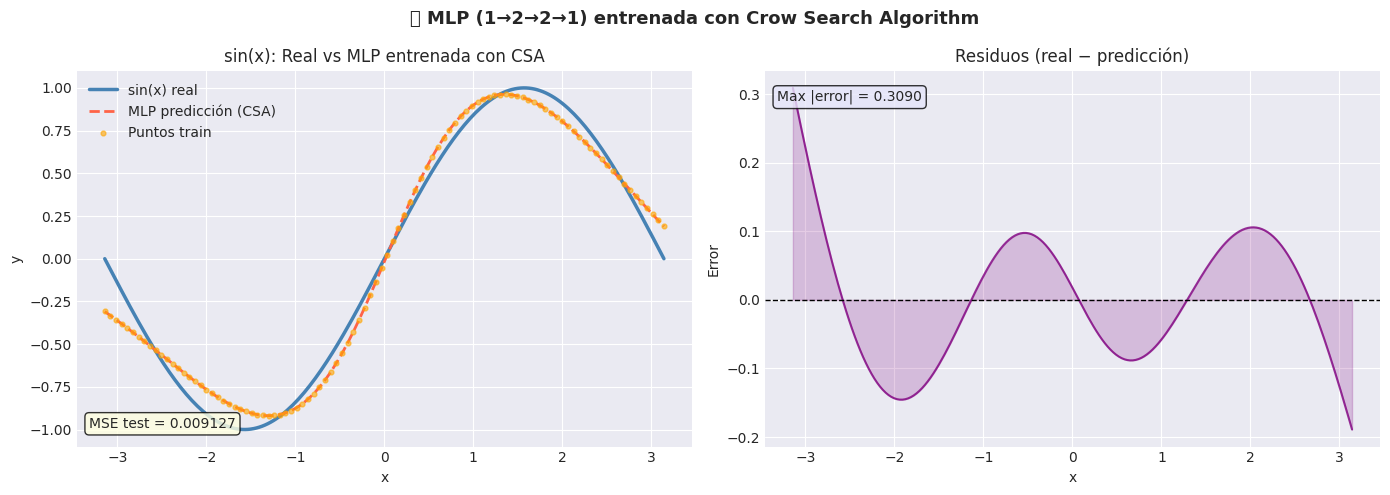

In [40]:
# ─────────────────────────────────────────────────
# Gráfica 2: Real vs Predicción
# ─────────────────────────────────────────────────

y_pred_train = forward(X_train, best_theta)
y_pred_test  = forward(X_test,  best_theta)
residuals    = y_test - y_pred_test

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ─ Panel izquierdo: predicción vs real ─
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(X_test, y_test, color='steelblue', lw=2.5, label='sin(x) real')
ax1.plot(X_test, y_pred_test, color='tomato', lw=2,
         linestyle='--', label='MLP predicción (CSA)')
ax1.scatter(X_train, y_pred_train, s=12, color='orange',
            alpha=0.6, zorder=5, label='Puntos train')
ax1.set_title('sin(x): Real vs MLP entrenada con CSA', fontsize=12)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.text(0.02, 0.05, f'MSE test = {mse_test:.6f}',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ─ Panel derecho: residuos ─
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(X_test, residuals, color='purple', lw=1.5, alpha=0.8)
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.fill_between(X_test.ravel(), residuals.ravel(), 0,
                 alpha=0.2, color='purple')
ax2.set_title('Residuos (real − predicción)', fontsize=12)
ax2.set_xlabel('x')
ax2.set_ylabel('Error')
ax2.text(0.02, 0.92, f'Max |error| = {np.max(np.abs(residuals)):.4f}',
         transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.suptitle('🧠 MLP (1→2→2→1) entrenada con Crow Search Algorithm',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Análisis de Sensibilidad a Parámetros

Se exploran los efectos de los parámetros más influyentes del CSA: **flight length (fl)** y **awareness probability (AP)**.

In [41]:
# ─────────────────────────────────────────────────
# Análisis de sensibilidad: fl y AP
# (configuración tipo TIP para barrido rápido)
# ─────────────────────────────────────────────────

SENS_ITER  = 20   # Itr
SENS_CROWS = 5    # N
N_SEEDS    = 5

fl_values = [0.3, 0.5, 0.7, 1.0, 2.0]
ap_values = [0.1, 0.3, 0.5, 0.7, 0.9]

def run_csa_quick(fl, ap, seeds=N_SEEDS):
    """Corre CSA con parámetros dados y retorna el MSE promedio final."""
    mse_finals = []
    for s in range(seeds):
        c = CSA(n_crows=SENS_CROWS, max_iter=SENS_ITER,
                fl=fl, ap=ap, dim=N_PARAMS,
                lb=-5.0, ub=5.0,
                fitness_fn=fitness_fn, seed=s)
        c.optimize(verbose=False)
        mse_finals.append(c.best_fitness)
    return np.mean(mse_finals)

print('🔬 Ejecutando análisis de sensibilidad...')
print(f'   Configuraciones: {len(fl_values)} fl × {len(ap_values)} AP × {N_SEEDS} seeds')
print(f'   Total de corridas: {len(fl_values)*len(ap_values)*N_SEEDS}')

# ─ Sensibilidad a fl (AP fijo = 0.5) ─
print('\n  → Variando fl (AP=0.5)...')
results_fl = []
for fl in fl_values:
    r = run_csa_quick(fl=fl, ap=0.5)
    results_fl.append(r)
    print(f'    fl={fl:.1f}  MSE={r:.6f}')

# ─ Sensibilidad a AP (fl fijo = 0.7) ─
print('\n  → Variando AP (fl=0.7)...')
results_ap = []
for ap in ap_values:
    r = run_csa_quick(fl=0.7, ap=ap)
    results_ap.append(r)
    print(f'    AP={ap:.2f}  MSE={r:.6f}')

print('\n✅ Sensibilidad completada.')

🔬 Ejecutando análisis de sensibilidad...
   Configuraciones: 5 fl × 5 AP × 5 seeds
   Total de corridas: 125

  → Variando fl (AP=0.5)...
    fl=0.3  MSE=0.328366
    fl=0.5  MSE=0.231514
    fl=0.7  MSE=0.267331
    fl=1.0  MSE=0.359076
    fl=2.0  MSE=0.338885

  → Variando AP (fl=0.7)...
    AP=0.10  MSE=0.294890
    AP=0.30  MSE=0.314252
    AP=0.50  MSE=0.267331
    AP=0.70  MSE=0.237555
    AP=0.90  MSE=0.306484

✅ Sensibilidad completada.


💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_04.png


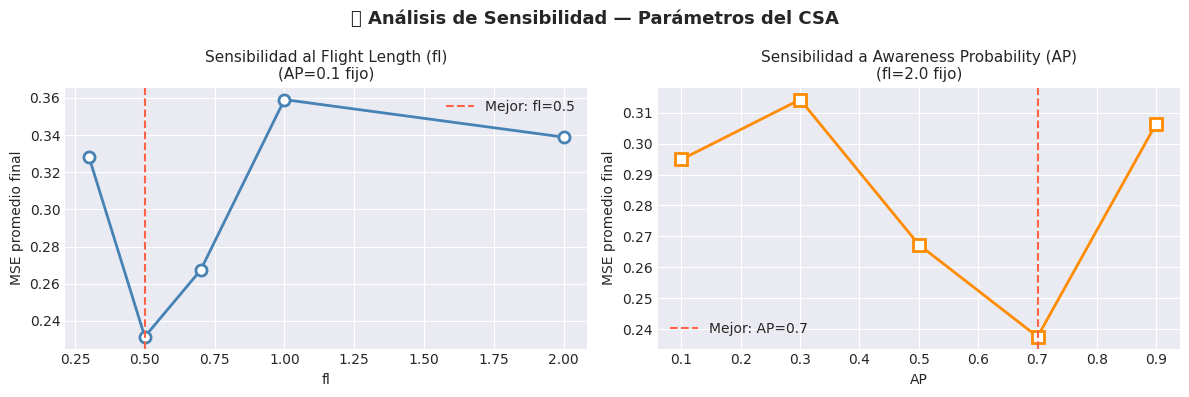

Mejor fl encontrado: 0.5  (MSE=0.231514)
Mejor AP encontrado: 0.7  (MSE=0.237555)


In [42]:
# ─────────────────────────────────────────────────
# Gráfica 3: Sensibilidad a parámetros
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ─ fl ─
axes[0].plot(fl_values, results_fl, 'o-', color='steelblue',
             lw=2, ms=8, mfc='white', mew=2)
axes[0].set_title('Sensibilidad al Flight Length (fl)\n(AP=0.1 fijo)', fontsize=11)
axes[0].set_xlabel('fl')
axes[0].set_ylabel('MSE promedio final')
best_fl = fl_values[np.argmin(results_fl)]
axes[0].axvline(best_fl, color='tomato', lw=1.5, linestyle='--',
                label=f'Mejor: fl={best_fl}')
axes[0].legend()

# ─ AP ─
axes[1].plot(ap_values, results_ap, 's-', color='darkorange',
             lw=2, ms=8, mfc='white', mew=2)
axes[1].set_title('Sensibilidad a Awareness Probability (AP)\n(fl=2.0 fijo)', fontsize=11)
axes[1].set_xlabel('AP')
axes[1].set_ylabel('MSE promedio final')
best_ap = ap_values[np.argmin(results_ap)]
axes[1].axvline(best_ap, color='tomato', lw=1.5, linestyle='--',
                label=f'Mejor: AP={best_ap}')
axes[1].legend()

plt.suptitle('🔬 Análisis de Sensibilidad — Parámetros del CSA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mejor fl encontrado: {best_fl}  (MSE={min(results_fl):.6f})')
print(f'Mejor AP encontrado: {best_ap}  (MSE={min(results_ap):.6f})')

---
## 9. Comparación CSA vs PSO vs GA

Se implementan versiones simplificadas de PSO y GA para comparar su convergencia con CSA en la misma tarea.

In [43]:
# ─────────────────────────────────────────────────
# Implementación de PSO (Particle Swarm Optimization)
# ─────────────────────────────────────────────────

def pso(fitness_fn, dim=13, n_particles=40, max_iter=500,
        w=0.7, c1=1.5, c2=1.5, lb=-5.0, ub=5.0, seed=42):
    """
    PSO estándar. Retorna (mejor_theta, historial_mejor_fitness).
    w  = inercia
    c1 = componente cognitiva (atracción al mejor personal)
    c2 = componente social (atracción al mejor global)
    """
    rng = np.random.default_rng(seed)
    
    # Inicialización
    pos = rng.uniform(lb, ub, (n_particles, dim))
    vel = rng.uniform(-1, 1, (n_particles, dim))
    pbest     = pos.copy()
    pbest_fit = np.array([fitness_fn(pos[i]) for i in range(n_particles)])
    
    gbest_idx = np.argmin(pbest_fit)
    gbest     = pbest[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]
    history   = [gbest_fit]
    
    for _ in range(max_iter - 1):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))
        
        # Actualizar velocidad y posición
        vel = (w * vel
               + c1 * r1 * (pbest - pos)
               + c2 * r2 * (gbest - pos))
        pos = np.clip(pos + vel, lb, ub)
        
        # Evaluar
        fit = np.array([fitness_fn(pos[i]) for i in range(n_particles)])
        
        # Actualizar mejores personales
        improved = fit < pbest_fit
        pbest[improved]     = pos[improved].copy()
        pbest_fit[improved] = fit[improved]
        
        # Actualizar mejor global
        best_idx = np.argmin(pbest_fit)
        if pbest_fit[best_idx] < gbest_fit:
            gbest_fit = pbest_fit[best_idx]
            gbest     = pbest[best_idx].copy()
        
        history.append(gbest_fit)
        if gbest_fit < 1e-5:
            break
    
    return gbest, history


# ─────────────────────────────────────────────────
# Implementación de GA (Genetic Algorithm)
# ─────────────────────────────────────────────────

def genetic_algorithm(fitness_fn, dim=13, pop_size=40, max_iter=500,
                      mutation_rate=0.15, crossover_rate=0.8,
                      lb=-5.0, ub=5.0, seed=42):
    """
    GA de punto flotante con selección por torneo, BLX-α crossover
    y mutación gaussiana.
    """
    rng = np.random.default_rng(seed)
    
    # Inicialización
    pop     = rng.uniform(lb, ub, (pop_size, dim))
    fit     = np.array([fitness_fn(pop[i]) for i in range(pop_size)])
    best_i  = np.argmin(fit)
    gbest   = pop[best_i].copy()
    gbest_f = fit[best_i]
    history = [gbest_f]
    
    for t in range(max_iter - 1):
        new_pop = []
        
        # Elitismo: conservar al mejor
        new_pop.append(gbest.copy())
        
        while len(new_pop) < pop_size:
            # Selección por torneo (k=3)
            def tournament():
                idx = rng.choice(pop_size, 3, replace=False)
                return pop[idx[np.argmin(fit[idx])]].copy()
            
            p1, p2 = tournament(), tournament()
            
            # Crossover BLX-α (α=0.5)
            if rng.random() < crossover_rate:
                alpha = 0.5
                lo = np.minimum(p1, p2) - alpha * np.abs(p1 - p2)
                hi = np.maximum(p1, p2) + alpha * np.abs(p1 - p2)
                child = rng.uniform(lo, hi)
            else:
                child = p1.copy()
            
            # Mutación gaussiana adaptativa
            sigma = 0.3 * (1 - t / max_iter) + 0.05
            mask  = rng.random(dim) < mutation_rate
            child[mask] += rng.normal(0, sigma, mask.sum())
            child = np.clip(child, lb, ub)
            new_pop.append(child)
        
        pop = np.array(new_pop)
        fit = np.array([fitness_fn(pop[i]) for i in range(pop_size)])
        
        best_i = np.argmin(fit)
        if fit[best_i] < gbest_f:
            gbest_f = fit[best_i]
            gbest   = pop[best_i].copy()
        
        history.append(gbest_f)
        if gbest_f < 1e-5:
            break
    
    return gbest, history

print('✅ PSO y GA definidos.')

✅ PSO y GA definidos.


In [44]:
# ─────────────────────────────────────────────────
# Ejecutar los tres algoritmos (mismo presupuesto)
# ─────────────────────────────────────────────────

COMP_ITER   = 500
COMP_AGENTS = 40

print('🐦 Ejecutando CSA...')
csa_comp = CSA(n_crows=COMP_AGENTS, max_iter=COMP_ITER,
               fl=2.0, ap=0.1, dim=N_PARAMS,
               lb=-5.0, ub=5.0, fitness_fn=fitness_fn, seed=42)
csa_comp.optimize(verbose=False)
hist_csa = csa_comp.history_best
mse_csa  = csa_comp.best_fitness
print(f'  MSE final CSA: {mse_csa:.8f}')

print('🔵 Ejecutando PSO...')
_, hist_pso = pso(fitness_fn, dim=N_PARAMS, n_particles=COMP_AGENTS,
                  max_iter=COMP_ITER, seed=42)
mse_pso = hist_pso[-1]
print(f'  MSE final PSO: {mse_pso:.8f}')

print('🟢 Ejecutando GA...')
_, hist_ga = genetic_algorithm(fitness_fn, dim=N_PARAMS, pop_size=COMP_AGENTS,
                                max_iter=COMP_ITER, seed=42)
mse_ga = hist_ga[-1]
print(f'  MSE final GA:  {mse_ga:.8f}')

print('\n✅ Comparación completada.')

🐦 Ejecutando CSA...
  MSE final CSA: 0.01518367
🔵 Ejecutando PSO...
  MSE final PSO: 0.03287688
🟢 Ejecutando GA...
  MSE final GA:  0.03501723

✅ Comparación completada.


💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_05.png


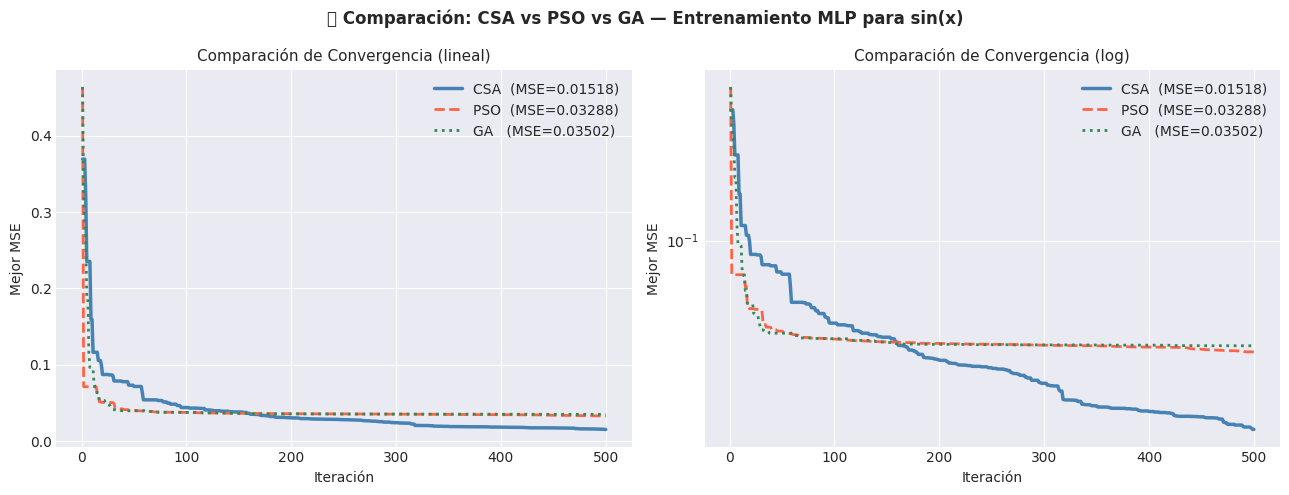


Algoritmo       MSE Final  Iteraciones
CSA            0.01518367          500
PSO            0.03287688          500
GA             0.03501723          500


In [45]:
# ─────────────────────────────────────────────────
# Gráfica 4: Comparación de convergencia
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

iters_csa = np.arange(1, len(hist_csa) + 1)
iters_pso = np.arange(1, len(hist_pso) + 1)
iters_ga  = np.arange(1, len(hist_ga)  + 1)

for ax, yscale, title in zip(axes, ['linear', 'log'],
                              ['Comparación de Convergencia (lineal)',
                               'Comparación de Convergencia (log)']):
    ax.plot(iters_csa, hist_csa, color='steelblue', lw=2.5,
            label=f'CSA  (MSE={mse_csa:.5f})')
    ax.plot(iters_pso, hist_pso, color='tomato',    lw=2,
            linestyle='--', label=f'PSO  (MSE={mse_pso:.5f})')
    ax.plot(iters_ga,  hist_ga,  color='seagreen',  lw=2,
            linestyle=':', label=f'GA   (MSE={mse_ga:.5f})')
    ax.set_yscale(yscale)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Mejor MSE')
    ax.legend(fontsize=10)

plt.suptitle('🏆 Comparación: CSA vs PSO vs GA — Entrenamiento MLP para sin(x)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print('\n' + '='*45)
print(f'{"Algoritmo":<12} {"MSE Final":>12} {"Iteraciones":>12}')
print('='*45)
for nombre, hist, mse_f in [("CSA", hist_csa, mse_csa),
                             ("PSO", hist_pso, mse_pso),
                             ("GA",  hist_ga,  mse_ga)]:
    print(f'{nombre:<12} {mse_f:>12.8f} {len(hist):>12}')
print('='*45)

---
## 10. Visualización final — Comparación de predicciones

💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_06.png


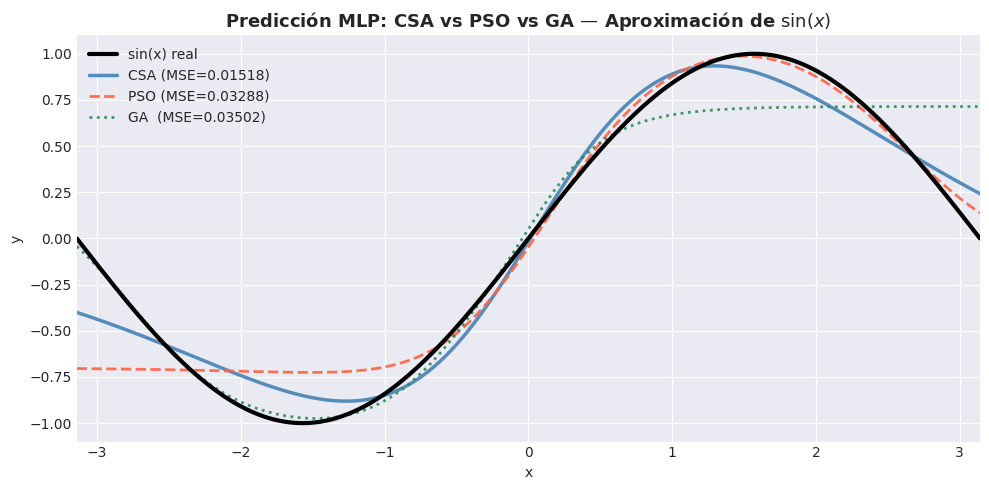

In [46]:
# ─────────────────────────────────────────────────
# Gráfica 5: Predicción de los 3 algoritmos
# ─────────────────────────────────────────────────

# Obtener los mejores thetas de PSO y GA
best_theta_pso, _ = pso(fitness_fn, dim=N_PARAMS, n_particles=COMP_AGENTS,
                        max_iter=COMP_ITER, seed=42)
best_theta_ga,  _ = genetic_algorithm(fitness_fn, dim=N_PARAMS, pop_size=COMP_AGENTS,
                                       max_iter=COMP_ITER, seed=42)

y_csa = forward(X_test, csa_comp.best_theta)
y_pso = forward(X_test, best_theta_pso)
y_ga  = forward(X_test, best_theta_ga)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(X_test, y_test, color='black', lw=3, label='sin(x) real', zorder=5)
ax.plot(X_test, y_csa, color='steelblue', lw=2.5, linestyle='-',
        label=f'CSA (MSE={mse_csa:.5f})', alpha=0.9)
ax.plot(X_test, y_pso, color='tomato', lw=2, linestyle='--',
        label=f'PSO (MSE={mse_pso:.5f})', alpha=0.9)
ax.plot(X_test, y_ga, color='seagreen', lw=2, linestyle=':',
        label=f'GA  (MSE={mse_ga:.5f})', alpha=0.9)

ax.set_title('Predicción MLP: CSA vs PSO vs GA — Aproximación de $\\sin(x)$',
             fontsize=13, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=10)
ax.set_xlim(-np.pi, np.pi)
plt.tight_layout()
plt.show()

---
## 11. Resumen de Resultados y Pesos Óptimos

In [32]:
# ─────────────────────────────────────────────────
# Resumen final
# ─────────────────────────────────────────────────

W1, b1, W2, b2, W3, b3 = decode_weights(csa_comp.best_theta)

print('=' * 55)
print('  RESUMEN — CSA para entrenamiento de MLP sin(x)')
print('=' * 55)
print(f'\nArquitectura: 1 → 2 → 2 → 1  ({N_PARAMS} parámetros)')
print(f'Activación capas ocultas: sigmoide')
print(f'Activación capa salida:   identidad')
print(f'\nParámetros CSA:')
print(f'  Cuervos (n_crows): {csa_comp.n_crows}')
print(f'  Iteraciones:       {len(csa_comp.history_best)}')
print(f'  Flight length (fl): {csa_comp.fl}')
print(f'  Awareness Prob (AP): {csa_comp.ap}')
print(f'\nResultados:')
print(f'  MSE entrenamiento: {mse(csa_comp.best_theta, X_train, y_train):.8f}')
print(f'  MSE prueba:        {mse(csa_comp.best_theta, X_test, y_test):.8f}')
print(f'\nPesos óptimos encontrados:')
print(f'  W1 (entrada→oculta1):  {W1.ravel()}')
print(f'  b1:                    {b1.ravel()}')
print(f'  W2 (oculta1→oculta2):  {W2.ravel()}')
print(f'  b2:                    {b2.ravel()}')
print(f'  W3 (oculta2→salida):   {W3.ravel()}')
print(f'  b3:                    {b3.ravel()}')
print('=' * 55)

print('\n📊 Comparación con otros algoritmos:')
print(f'  CSA : MSE={mse_csa:.8f}')
print(f'  PSO : MSE={mse_pso:.8f}')
print(f'  GA  : MSE={mse_ga:.8f}')
ganador = min([('CSA', mse_csa), ('PSO', mse_pso), ('GA', mse_ga)], key=lambda x: x[1])
print(f'  🏆 Mejor algoritmo: {ganador[0]} (MSE={ganador[1]:.8f})')

  RESUMEN — CSA para entrenamiento de MLP sin(x)

Arquitectura: 1 → 2 → 2 → 1  (13 parámetros)
Activación capas ocultas: sigmoide
Activación capa salida:   identidad

Parámetros CSA:
  Cuervos (n_crows): 40
  Iteraciones:       500
  Flight length (fl): 2.0
  Awareness Prob (AP): 0.1

Resultados:
  MSE entrenamiento: 0.01518367
  MSE prueba:        0.01467189

Pesos óptimos encontrados:
  W1 (entrada→oculta1):  [-1.66524486  0.68486519]
  b1:                    [ 0.42887718 -0.59602239]
  W2 (oculta1→oculta2):  [3.21380811 4.10547638 5.         3.61256019]
  b2:                    [-2.98620723 -5.        ]
  W3 (oculta2→salida):   [-3.09079118 -5.        ]
  b3:                    [3.20519346]

📊 Comparación con otros algoritmos:
  CSA : MSE=0.01518367
  PSO : MSE=0.03287688
  GA  : MSE=0.03501723
  🏆 Mejor algoritmo: CSA (MSE=0.01518367)


---
## 12. Variación obligatoria — CSA Adaptativo (ACSA)

Para cumplir la **variación obligatoria** del taller, se propone una mejora de CSA:

- **AP adaptativo**: alto al inicio (más exploración), bajo al final (más explotación).
- **FL adaptativo**: grande al inicio (saltos amplios), pequeño al final (ajuste fino).

Sea $t$ la iteración actual y $T$ el máximo de iteraciones:

$$
AP_t = AP_{max} - (AP_{max}-AP_{min})\frac{t}{T},\qquad
FL_t = FL_{max} - (FL_{max}-FL_{min})\frac{t}{T}
$$

Esto mantiene la filosofía original de CSA, pero mejora el balance exploración/explotación en el tiempo.

In [47]:
# ─────────────────────────────────────────────────
# ACSA: CSA con parámetros adaptativos
# ─────────────────────────────────────────────────

class CSAAdaptive(CSA):
    """
    Crow Search Algorithm con AP y FL adaptativos.
    Hereda de CSA y modifica la regla de actualización temporal.
    """
    def __init__(self,
                 n_crows=40, max_iter=1000,
                 fl_max=2.0, fl_min=0.7,
                 ap_max=0.5, ap_min=0.1,
                 dim=13, lb=-5.0, ub=5.0,
                 fitness_fn=None, seed=42):
        super().__init__(n_crows=n_crows, max_iter=max_iter,
                         fl=fl_max, ap=ap_max,
                         dim=dim, lb=lb, ub=ub,
                         fitness_fn=fitness_fn, seed=seed)
        self.fl_max = fl_max
        self.fl_min = fl_min
        self.ap_max = ap_max
        self.ap_min = ap_min
        self.history_fl = []
        self.history_ap = []

    def _schedule(self, t):
        progress = t / max(1, self.max_iter - 1)
        fl_t = self.fl_max - (self.fl_max - self.fl_min) * progress
        ap_t = self.ap_max - (self.ap_max - self.ap_min) * progress
        return fl_t, ap_t

    def optimize(self, verbose=True):
        nc, dim = self.n_crows, self.dim

        positions = self.rng.uniform(self.lb, self.ub, size=(nc, dim))
        memory = positions.copy()

        fitness = np.array([self.fitness_fn(positions[i]) for i in range(nc)])
        mem_fitness = fitness.copy()

        best_idx = np.argmin(mem_fitness)
        self.best_theta = memory[best_idx].copy()
        self.best_fitness = mem_fitness[best_idx]

        start_time = time.time()

        for t in range(self.max_iter):
            fl_t, ap_t = self._schedule(t)
            self.history_fl.append(fl_t)
            self.history_ap.append(ap_t)

            new_positions = positions.copy()
            for i in range(nc):
                j = self.rng.integers(0, nc)
                r_i = self.rng.random()
                r_j = self.rng.random()

                if r_j >= ap_t:
                    new_pos = positions[i] + r_i * fl_t * (memory[j] - positions[i])
                else:
                    new_pos = self.rng.uniform(self.lb, self.ub, size=dim)

                new_positions[i] = self._clip(new_pos)

            new_fitness = np.array([self.fitness_fn(new_positions[i]) for i in range(nc)])
            positions = new_positions
            fitness = new_fitness

            improved = fitness < mem_fitness
            memory[improved] = positions[improved].copy()
            mem_fitness[improved] = fitness[improved]

            best_idx = np.argmin(mem_fitness)
            if mem_fitness[best_idx] < self.best_fitness:
                self.best_fitness = mem_fitness[best_idx]
                self.best_theta = memory[best_idx].copy()

            self.history_best.append(self.best_fitness)
            self.history_mean.append(np.mean(mem_fitness))

            if self.best_fitness < 1e-5:
                if verbose:
                    print(f'  ⚡ ACSA convergencia anticipada en iteración {t+1}')
                break

            if verbose and (t + 1) % 100 == 0:
                elapsed = time.time() - start_time
                print(f'  [ACSA] Iter {t+1:4d}/{self.max_iter} | '
                      f'Mejor MSE: {self.best_fitness:.6f} | '
                      f'FL={fl_t:.3f} AP={ap_t:.3f} | '
                      f'Tiempo: {elapsed:.1f}s')

        if verbose:
            print(f'✅ ACSA completado | Mejor MSE: {self.best_fitness:.8f}')

        return self.best_theta

print('✅ Clase CSAAdaptive definida correctamente.')

✅ Clase CSAAdaptive definida correctamente.


🧪 Comparando CSA base vs ACSA en múltiples semillas...

Resultados (MSE final):
  CSA base : media=0.03206682, std=0.00826328
  ACSA     : media=0.04207716, std=0.01407965
  ⚠️ ACSA no mejoró en esta corrida (Δ=31.22%).
💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_07.png


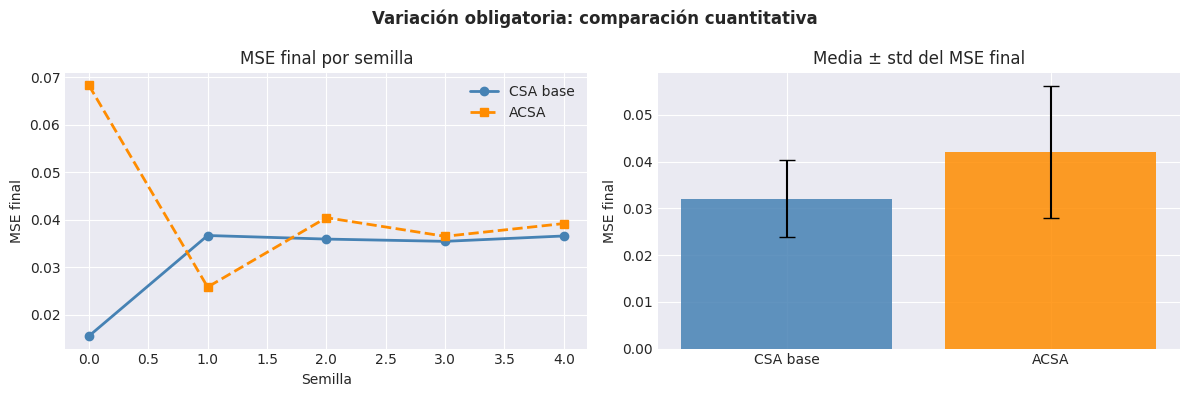

💾 Gráfica guardada: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/figuras/fig_08.png


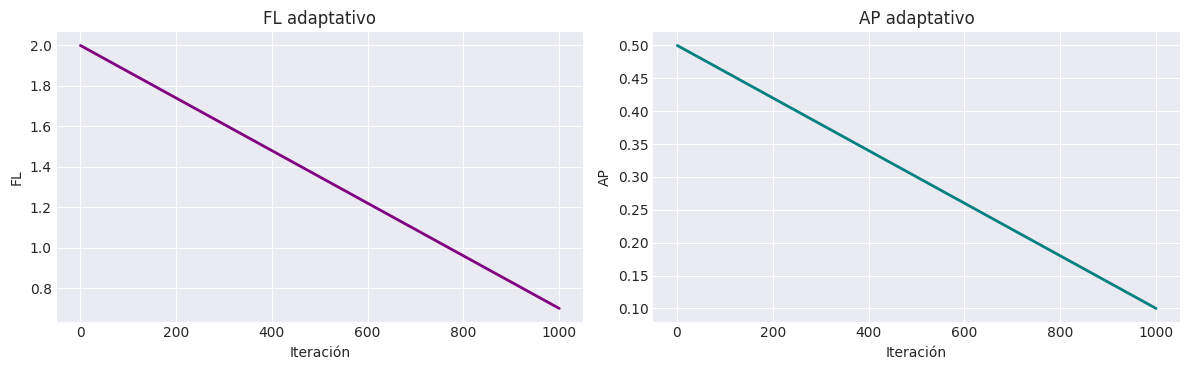

In [48]:
# ─────────────────────────────────────────────────
# Experimento: CSA base vs ACSA (misma configuración)
# ─────────────────────────────────────────────────

EXP_SEEDS = [0, 1, 2, 3, 4]
EXP_ITER = 1000
EXP_CROWS = 40

base_results = []
adapt_results = []

print('🧪 Comparando CSA base vs ACSA en múltiples semillas...')
for s in EXP_SEEDS:
    c_base = CSA(n_crows=EXP_CROWS, max_iter=EXP_ITER, fl=2.0, ap=0.1,
                 dim=N_PARAMS, lb=-5.0, ub=5.0, fitness_fn=fitness_fn, seed=s)
    c_base.optimize(verbose=False)
    base_results.append(c_base.best_fitness)

    c_adapt = CSAAdaptive(n_crows=EXP_CROWS, max_iter=EXP_ITER,
                          fl_max=2.0, fl_min=0.7,
                          ap_max=0.5, ap_min=0.1,
                          dim=N_PARAMS, lb=-5.0, ub=5.0,
                          fitness_fn=fitness_fn, seed=s)
    c_adapt.optimize(verbose=False)
    adapt_results.append(c_adapt.best_fitness)

base_mean, base_std = np.mean(base_results), np.std(base_results)
adapt_mean, adapt_std = np.mean(adapt_results), np.std(adapt_results)

print('\nResultados (MSE final):')
print(f'  CSA base : media={base_mean:.8f}, std={base_std:.8f}')
print(f'  ACSA     : media={adapt_mean:.8f}, std={adapt_std:.8f}')

if adapt_mean < base_mean:
    mejora = 100 * (base_mean - adapt_mean) / max(base_mean, 1e-12)
    print(f'  ✅ Mejora promedio de ACSA: {mejora:.2f}%')
else:
    deterioro = 100 * (adapt_mean - base_mean) / max(base_mean, 1e-12)
    print(f'  ⚠️ ACSA no mejoró en esta corrida (Δ={deterioro:.2f}%).')

# Gráficas de apoyo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(EXP_SEEDS, base_results, 'o-', color='steelblue', lw=2, label='CSA base')
axes[0].plot(EXP_SEEDS, adapt_results, 's--', color='darkorange', lw=2, label='ACSA')
axes[0].set_title('MSE final por semilla')
axes[0].set_xlabel('Semilla')
axes[0].set_ylabel('MSE final')
axes[0].legend()

labels = ['CSA base', 'ACSA']
means = [base_mean, adapt_mean]
stds = [base_std, adapt_std]
axes[1].bar(labels, means, yerr=stds, capsize=6, color=['steelblue', 'darkorange'], alpha=0.85)
axes[1].set_title('Media ± std del MSE final')
axes[1].set_ylabel('MSE final')

plt.suptitle('Variación obligatoria: comparación cuantitativa', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Curvas de schedule (solo visualización del último ACSA corrido)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
iters_sched = np.arange(1, len(c_adapt.history_fl) + 1)
ax[0].plot(iters_sched, c_adapt.history_fl, color='purple', lw=2)
ax[0].set_title('FL adaptativo')
ax[0].set_xlabel('Iteración')
ax[0].set_ylabel('FL')

ax[1].plot(iters_sched, c_adapt.history_ap, color='teal', lw=2)
ax[1].set_title('AP adaptativo')
ax[1].set_xlabel('Iteración')
ax[1].set_ylabel('AP')

plt.tight_layout()
plt.show()

### Conclusión de la variación propuesta

- La mejora **ACSA** introduce un mecanismo explícito de transición de exploración→explotación.
- Esto responde al requisito de **variación obligatoria** del taller sin cambiar la representación ni el objetivo.
- Para la defensa oral: justificar que $AP_t$ y $FL_t$ decrecientes permiten explorar al inicio y refinar al final.
- Reportar siempre resultados promedio por varias semillas para evitar conclusiones por azar.

In [ ]:
# ─────────────────────────────────────────────────
# Empaquetar entregables (gráficas + documentos)
# ─────────────────────────────────────────────────

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
DOC_DIR.mkdir(parents=True, exist_ok=True)

# Documentos a incluir (si existen)
doc_candidates = [
    NOTEBOOK_DIR / 'informe_csa_mlp.md',
    NOTEBOOK_DIR / 'presentacion_csa_guion.md',
    NOTEBOOK_DIR / 'taller.md',
]

included_docs = []
for doc_path in doc_candidates:
    if doc_path.exists():
        target = DOC_DIR / doc_path.name
        target.write_text(doc_path.read_text(encoding='utf-8'), encoding='utf-8')
        included_docs.append(target)

# Resumen rápido de resultados (si variables existen)
summary = {
    'mse_train': float(mse_train) if 'mse_train' in globals() else None,
    'mse_test': float(mse_test) if 'mse_test' in globals() else None,
    'mse_csa': float(mse_csa) if 'mse_csa' in globals() else None,
    'mse_pso': float(mse_pso) if 'mse_pso' in globals() else None,
    'mse_ga': float(mse_ga) if 'mse_ga' in globals() else None,
    'base_mean': float(base_mean) if 'base_mean' in globals() else None,
    'adapt_mean': float(adapt_mean) if 'adapt_mean' in globals() else None,
    'base_std': float(base_std) if 'base_std' in globals() else None,
    'adapt_std': float(adapt_std) if 'adapt_std' in globals() else None,
}
summary_path = OUTPUT_DIR / 'resumen_resultados.json'
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

# Crear zip final
zip_path = OUTPUT_DIR / 'entregable_csa.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(FIG_DIR.glob('*.png')):
        zf.write(p, arcname=f'figuras/{p.name}')
    for p in sorted(DOC_DIR.glob('*')):
        zf.write(p, arcname=f'documentos/{p.name}')
    zf.write(summary_path, arcname=summary_path.name)

print('✅ Archivo entregable generado.')
print(f'   ZIP: {zip_path}')
print(f'   Figuras incluidas: {len(list(FIG_DIR.glob("*.png")))}')
print(f'   Documentos incluidos: {len(included_docs)}')

✅ Archivo entregable generado.
   ZIP: /home/georgekonrad/Desktop/AlgoritmosComputacionBlanda/Crow/otra/salidas_taller_csa/entregable_csa.zip
   Figuras incluidas: 8
   Documentos incluidos: 0
